In [100]:
import os
import sys
#pointing python to project root
sys.path.insert(0, os.path.abspath(".."))
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import text
from ingestion.db import get_engine
import warnings

warnings.filterwarnings("ignore")

engine =  get_engine()
df = pd.read_sql("SELECT * FROM weather_readings ORDER BY timestamp ASC", engine)
print(f"Loaded {len(df)} rows")

df.head()


Loaded 744 rows


,id,timestamp,station_id,temperature_2m,shortwave_radiation,windspeed_10m,wind_direction_10m,wind_gusts_10m,relative_humidity_2m,rain,cloud_cover,soil_temperature_7_to_28cm,soil_moisture_7_to_28cm
0,1,2024-01-01 00:00:00,plateau_jos,17.0,0.0,9.4,88.0,14.8,36.0,0.0,0.0,22.8,0.28
1,2,2024-01-01 01:00:00,plateau_jos,17.7,0.0,8.3,90.0,11.9,34.0,0.0,0.0,22.7,0.28
2,3,2024-01-01 02:00:00,plateau_jos,17.9,0.0,8.4,80.0,11.5,33.0,0.0,0.0,22.5,0.28
3,4,2024-01-01 03:00:00,plateau_jos,17.8,0.0,8.7,85.0,10.8,33.0,0.0,0.0,22.3,0.28
4,5,2024-01-01 04:00:00,plateau_jos,17.0,0.0,9.5,81.0,11.9,35.0,0.0,0.0,22.1,0.28


In [101]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 744 entries, 0 to 743
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   id                          744 non-null    int64         
 1   timestamp                   744 non-null    datetime64[ns]
 2   station_id                  744 non-null    object        
 3   temperature_2m              744 non-null    float64       
 4   shortwave_radiation         744 non-null    float64       
 5   windspeed_10m               744 non-null    float64       
 6   wind_direction_10m          744 non-null    float64       
 7   wind_gusts_10m              744 non-null    float64       
 8   relative_humidity_2m        744 non-null    float64       
 9   rain                        744 non-null    float64       
 10  cloud_cover                 744 non-null    float64       
 11  soil_temperature_7_to_28cm  744 non-null    float64       

In [28]:
df.describe()

,id,timestamp,temperature_2m,shortwave_radiation,windspeed_10m,wind_direction_10m,wind_gusts_10m,relative_humidity_2m,rain,cloud_cover,soil_temperature_7_to_28cm,soil_moisture_7_to_28cm
count,744.000000,744,744.000000,744.000000,744.00000,744.000000,744.000000,744.000000,744.0,744.000000,744.000000,744.000000
mean,372.500000,2024-01-16 11:29:59.999999744,19.986290,265.766129,10.71129,67.786290,20.952285,22.350806,0.0,16.610215,21.811559,0.278559
min,1.000000,2024-01-01 00:00:00,10.600000,0.000000,1.10000,15.000000,3.600000,8.000000,0.0,0.000000,19.400000,0.277000
25%,186.750000,2024-01-08 17:45:00,15.675000,0.000000,9.00000,53.000000,14.800000,16.000000,0.0,0.000000,21.100000,0.278000
50%,372.500000,2024-01-16 11:30:00,18.900000,2.000000,11.00000,65.000000,19.100000,22.000000,0.0,0.000000,21.800000,0.279000
75%,558.250000,2024-01-24 05:15:00,24.700000,584.250000,12.40000,75.000000,27.700000,28.000000,0.0,10.250000,22.500000,0.279000
max,744.000000,2024-01-31 23:00:00,30.200000,965.000000,18.50000,360.000000,40.700000,45.000000,0.0,100.000000,23.900000,0.280000
std,214.918589,NaN,5.174414,347.754692,2.59034,31.023089,7.591927,7.723994,0.0,32.458296,1.023453,0.000895


In [29]:
print("shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())

shape: (744, 13)

Missing values:
 id                            0
timestamp                     0
station_id                    0
temperature_2m                0
shortwave_radiation           0
windspeed_10m                 0
wind_direction_10m            0
wind_gusts_10m                0
relative_humidity_2m          0
rain                          0
cloud_cover                   0
soil_temperature_7_to_28cm    0
soil_moisture_7_to_28cm       0
dtype: int64


In [30]:
#fixin datatypes
df["timestamp"] = pd.to_datetime(df["timestamp"])
df["station_id"] = df["station_id"].astype(str)

In [31]:
sensor_cols = [
    "temperature_2m", "shortwave_radiation", "windspeed_10m",
    "wind_direction_10m", "wind_gusts_10m", "relative_humidity_2m",
    "rain", "cloud_cover", "soil_temperature_7_to_28cm", "soil_moisture_7_to_28cm"
]

# for col in sensor_cols:
#     df[f"{col}_missing"] = df[col].isnull().astype(int)


## Removing outliers

In [32]:
bounds = {
    "temperature_2m":             (-10, 50),
    "shortwave_radiation":        (0, 1200),
    "windspeed_10m":              (0, 150),
    "wind_gusts_10m":             (0, 200),
    "relative_humidity_2m":       (0, 100),
    "rain":                       (0, 200),
    "cloud_cover":                (0, 100),
    "soil_temperature_7_to_28cm": (0, 60),
    "soil_moisture_7_to_28cm":    (0, 1.0),
}

for col, (low, high) in bounds.items():
    if col in df.columns:
        mask = (df[col] < low) | (df[col] > high)
        if mask.sum() > 0:
            print(f"{col}: {mask.sum()} outliers removed")
            df.loc[mask, col] = np.nan



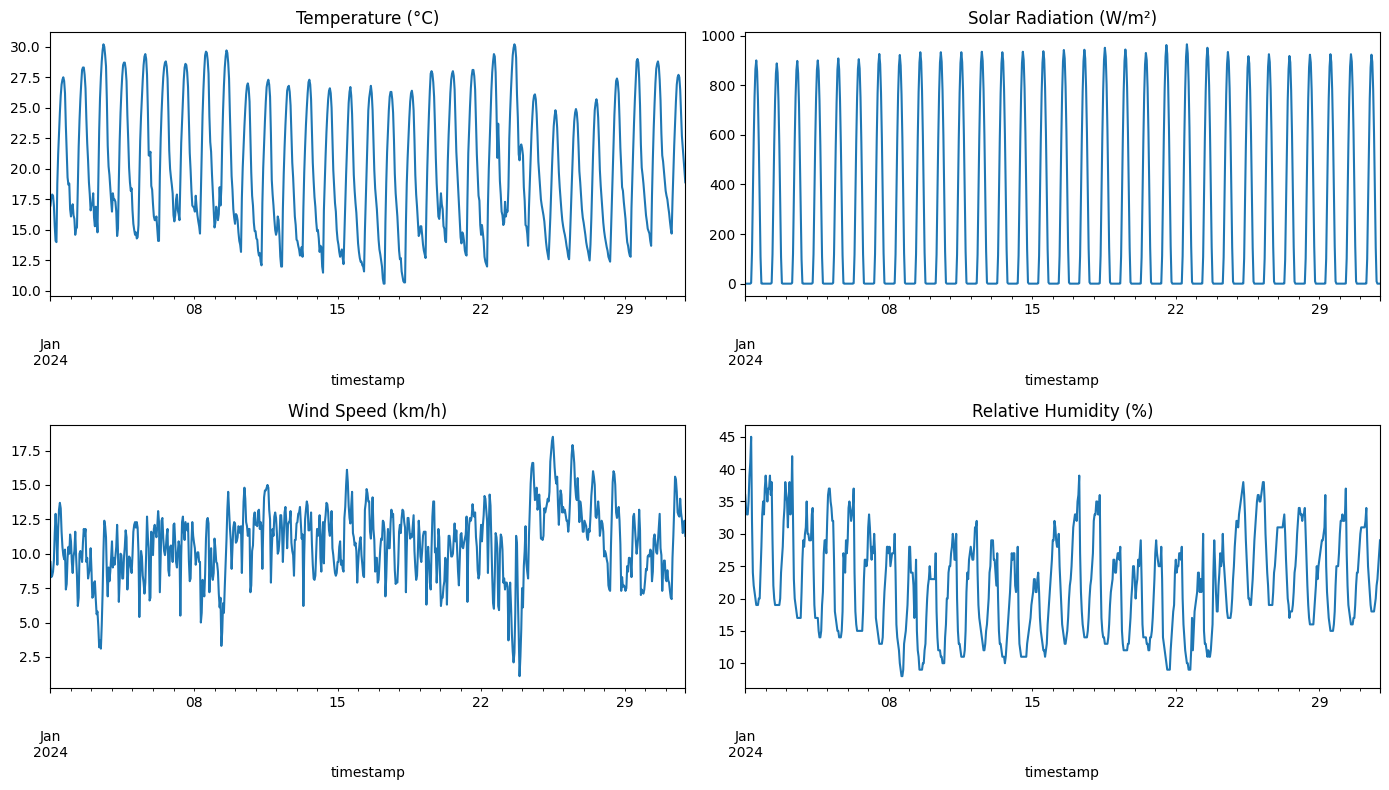

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

df.plot(x="timestamp", y="temperature_2m", ax=axes[0,0], title="Temperature (°C)", legend=False)
df.plot(x="timestamp", y="shortwave_radiation", ax=axes[0,1], title="Solar Radiation (W/m²)", legend=False)
df.plot(x="timestamp", y="windspeed_10m", ax=axes[1,0], title="Wind Speed (km/h)", legend=False)
df.plot(x="timestamp", y="relative_humidity_2m", ax=axes[1,1], title="Relative Humidity (%)", legend=False)

plt.tight_layout()
plt.show()

In [34]:
df.head()

,id,timestamp,station_id,temperature_2m,shortwave_radiation,windspeed_10m,wind_direction_10m,wind_gusts_10m,relative_humidity_2m,rain,cloud_cover,soil_temperature_7_to_28cm,soil_moisture_7_to_28cm
0,1,2024-01-01 00:00:00,plateau_jos,17.0,0.0,9.4,88.0,14.8,36.0,0.0,0.0,22.8,0.28
1,2,2024-01-01 01:00:00,plateau_jos,17.7,0.0,8.3,90.0,11.9,34.0,0.0,0.0,22.7,0.28
2,3,2024-01-01 02:00:00,plateau_jos,17.9,0.0,8.4,80.0,11.5,33.0,0.0,0.0,22.5,0.28
3,4,2024-01-01 03:00:00,plateau_jos,17.8,0.0,8.7,85.0,10.8,33.0,0.0,0.0,22.3,0.28
4,5,2024-01-01 04:00:00,plateau_jos,17.0,0.0,9.5,81.0,11.9,35.0,0.0,0.0,22.1,0.28


## Day 04 - EDA

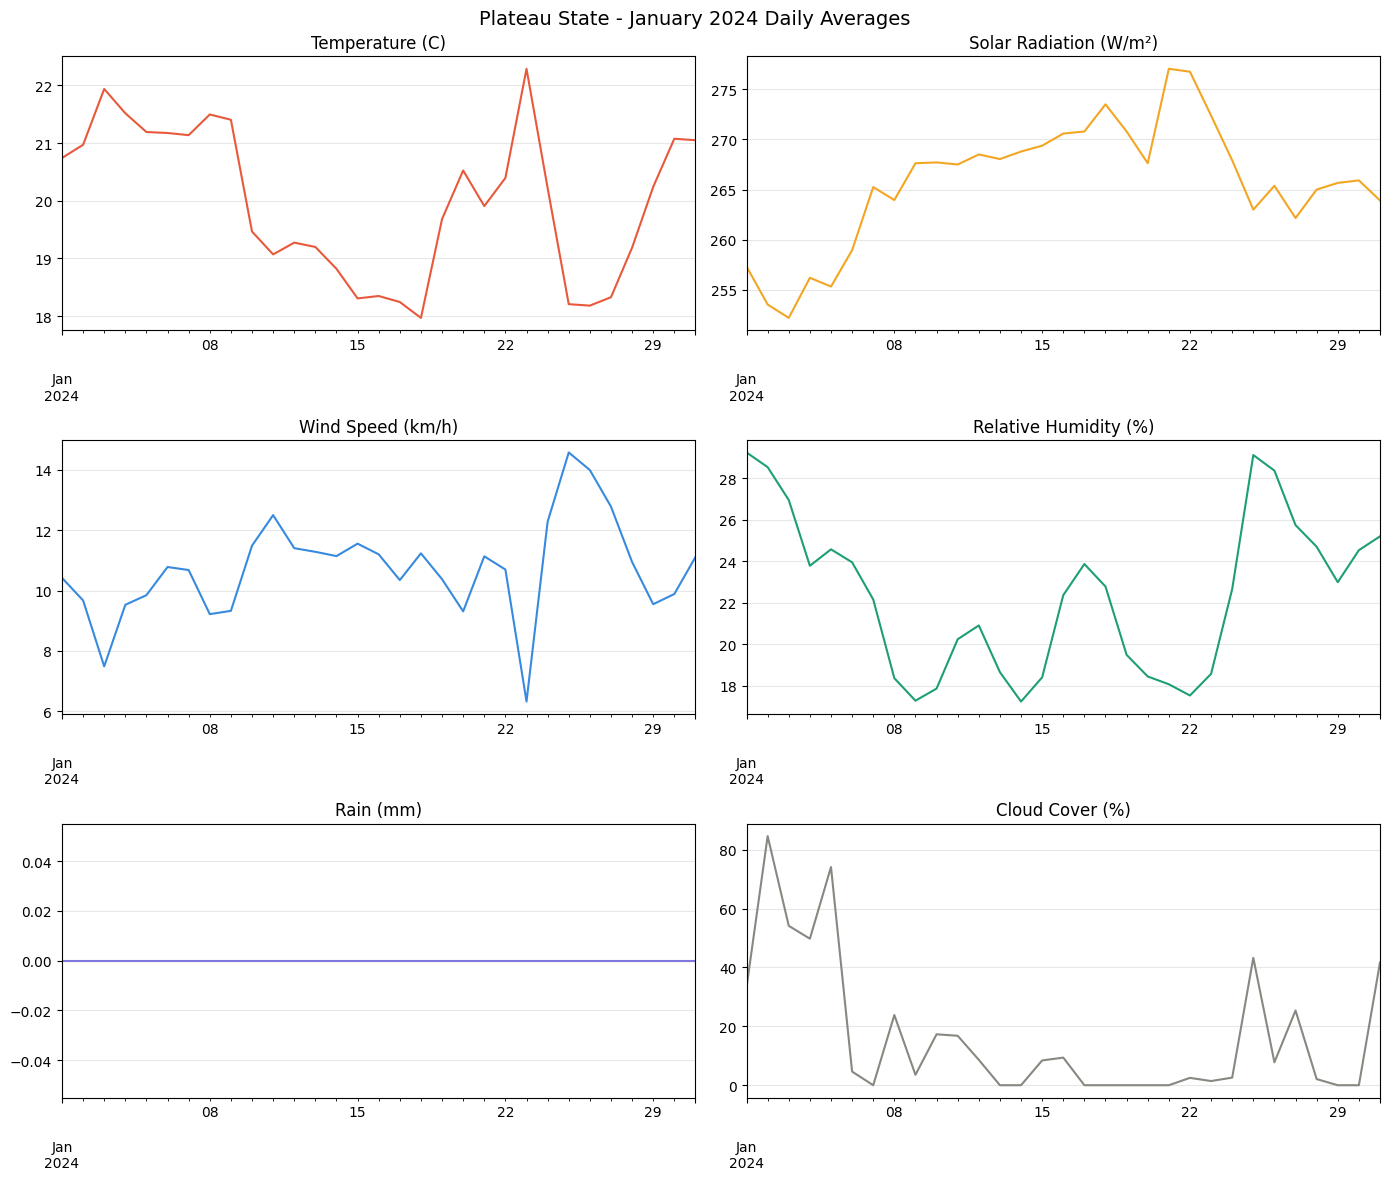

In [43]:
df_plot = df.set_index("timestamp")
daily = df_plot.resample("D").mean(numeric_only=True)

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
fig.suptitle("Plateau State - January 2024 Daily Averages", fontsize=14)

daily["temperature_2m"].plot(ax=axes[0,0], title="Temperature (C)", color="#E8593C")
daily["shortwave_radiation"].plot(ax=axes[0,1], title="Solar Radiation (W/m²)", color="#F2A623")
daily["windspeed_10m"].plot(ax=axes[1,0], title="Wind Speed (km/h)", color="#378ADD")
daily["relative_humidity_2m"].plot(ax=axes[1,1], title="Relative Humidity (%)", color="#1D9E75")
daily["rain"].plot(ax=axes[2,0], title="Rain (mm)", color="#7F77DD")
daily["cloud_cover"].plot(ax=axes[2,1], title="Cloud Cover (%)", color="#888780")

for ax in axes.flat:
    ax.set_xlabel("")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [51]:
df_plot.head()
# daily.head()

,id,station_id,temperature_2m,shortwave_radiation,windspeed_10m,wind_direction_10m,wind_gusts_10m,relative_humidity_2m,rain,cloud_cover,soil_temperature_7_to_28cm,soil_moisture_7_to_28cm
timestamp,,,,,,,,,,,,
2024-01-01 00:00:00,1,plateau_jos,17.0,0.0,9.4,88.0,14.8,36.0,0.0,0.0,22.8,0.28
2024-01-01 01:00:00,2,plateau_jos,17.7,0.0,8.3,90.0,11.9,34.0,0.0,0.0,22.7,0.28
2024-01-01 02:00:00,3,plateau_jos,17.9,0.0,8.4,80.0,11.5,33.0,0.0,0.0,22.5,0.28
2024-01-01 03:00:00,4,plateau_jos,17.8,0.0,8.7,85.0,10.8,33.0,0.0,0.0,22.3,0.28
2024-01-01 04:00:00,5,plateau_jos,17.0,0.0,9.5,81.0,11.9,35.0,0.0,0.0,22.1,0.28


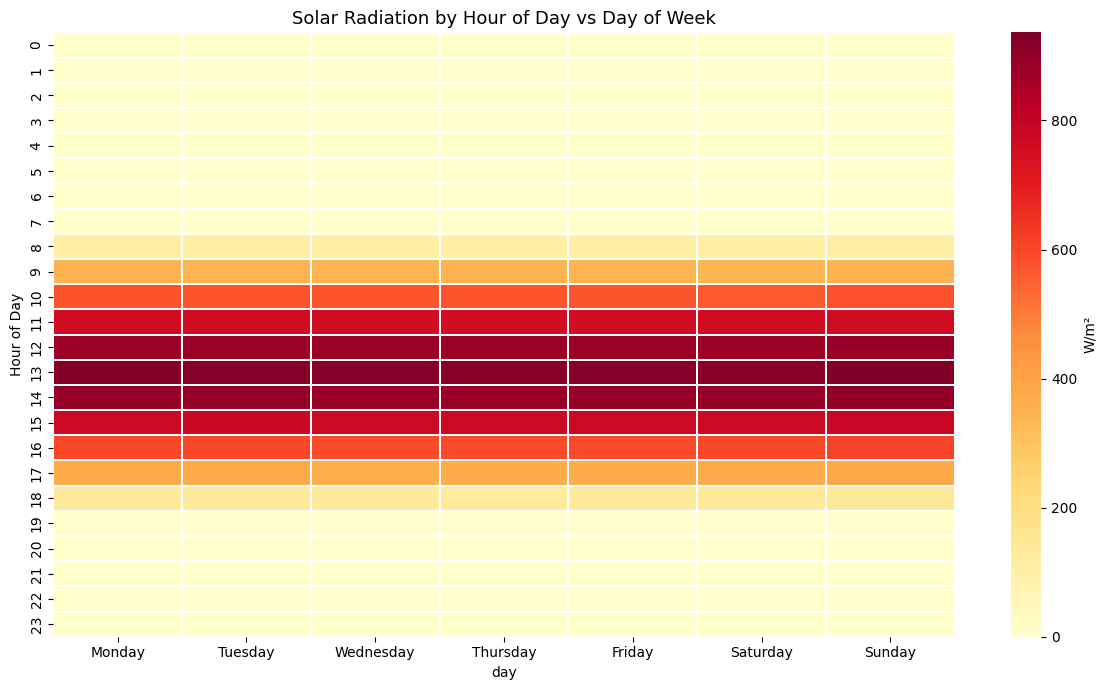

In [50]:
df_heat = df_plot.copy()
df_heat["hour"] = df_heat.index.hour
df_heat["day"] = df_heat.index.day_name()
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

pivot = df_heat.pivot_table(
    values="shortwave_radiation",
    index="hour",
    columns="day",
    aggfunc="mean"
)[day_order]

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(pivot, cmap="YlOrRd", ax=ax, linewidths=0.3, cbar_kws={"label": "W/m²"})
ax.set_title("Solar Radiation by Hour of Day vs Day of Week", fontsize=13)
ax.set_ylabel("Hour of Day")
plt.tight_layout()
plt.show()

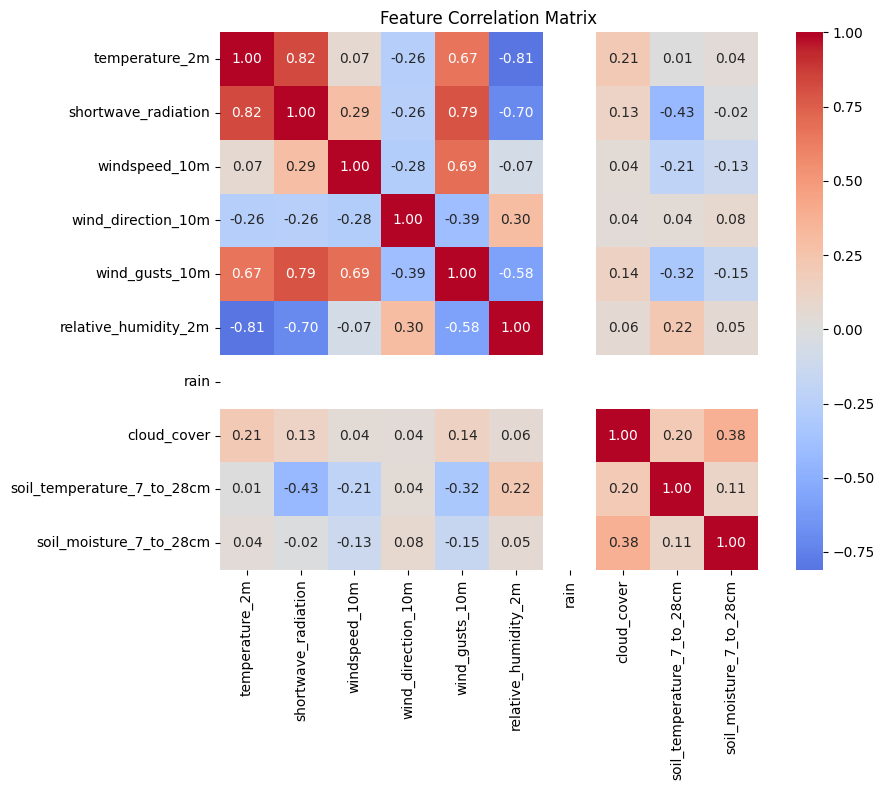

In [56]:
#correlation

fig, ax = plt.subplots(figsize=(10,8))
sns.heatmap(df[sensor_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax, square=True)
ax.set_title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In [57]:
peak_solar_hour = df_plot.groupby(df_plot.index.hour)["shortwave_radiation"].mean().idxmax()
peak_temp_hour  = df_plot.groupby(df_plot.index.hour)["temperature_2m"].mean().idxmax()

print("Key EDA Findings")
print(f"Peak solar radiation hour : {peak_solar_hour}:00")
print(f"Peak temperature hour     : {peak_temp_hour}:00")
print(f"Average wind speed        : {df['windspeed_10m'].mean():.1f} km/h")
print(f"Max solar radiation       : {df['shortwave_radiation'].max():.1f} W/m²")

Key EDA Findings
Peak solar radiation hour : 13:00
Peak temperature hour     : 15:00
Average wind speed        : 10.7 km/h
Max solar radiation       : 965.0 W/m²


Day 5 -Feature Engineering

In [58]:
df.head()

,id,timestamp,station_id,temperature_2m,shortwave_radiation,windspeed_10m,wind_direction_10m,wind_gusts_10m,relative_humidity_2m,rain,cloud_cover,soil_temperature_7_to_28cm,soil_moisture_7_to_28cm
0,1,2024-01-01 00:00:00,plateau_jos,17.0,0.0,9.4,88.0,14.8,36.0,0.0,0.0,22.8,0.28
1,2,2024-01-01 01:00:00,plateau_jos,17.7,0.0,8.3,90.0,11.9,34.0,0.0,0.0,22.7,0.28
2,3,2024-01-01 02:00:00,plateau_jos,17.9,0.0,8.4,80.0,11.5,33.0,0.0,0.0,22.5,0.28
3,4,2024-01-01 03:00:00,plateau_jos,17.8,0.0,8.7,85.0,10.8,33.0,0.0,0.0,22.3,0.28
4,5,2024-01-01 04:00:00,plateau_jos,17.0,0.0,9.5,81.0,11.9,35.0,0.0,0.0,22.1,0.28


In [60]:
df = df.set_index("timestamp").sort_index()
df.head()

,id,station_id,temperature_2m,shortwave_radiation,windspeed_10m,wind_direction_10m,wind_gusts_10m,relative_humidity_2m,rain,cloud_cover,soil_temperature_7_to_28cm,soil_moisture_7_to_28cm
timestamp,,,,,,,,,,,,
2024-01-01 00:00:00,1,plateau_jos,17.0,0.0,9.4,88.0,14.8,36.0,0.0,0.0,22.8,0.28
2024-01-01 01:00:00,2,plateau_jos,17.7,0.0,8.3,90.0,11.9,34.0,0.0,0.0,22.7,0.28
2024-01-01 02:00:00,3,plateau_jos,17.9,0.0,8.4,80.0,11.5,33.0,0.0,0.0,22.5,0.28
2024-01-01 03:00:00,4,plateau_jos,17.8,0.0,8.7,85.0,10.8,33.0,0.0,0.0,22.3,0.28
2024-01-01 04:00:00,5,plateau_jos,17.0,0.0,9.5,81.0,11.9,35.0,0.0,0.0,22.1,0.28


In [61]:
df["hour"] = df.index.hour
df["day_of_week"] = df.index.dayofweek
df["month"] = df.index.month
df["is_weekend"] = (df.index.dayofweek >= 5).astype(int)

df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
df["day_of_week_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["day_of_weel_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)

print("Time + cyclical features added")

Time + cyclical features added


In [62]:
target_cols = ["temperature_2m", "shortwave_radiation", "windspeed_10m", "relative_humidity_2m"]

for col in target_cols:
    df[f"{col}_lag1"]  = df[col].shift(1)
    df[f"{col}_lag2"]  = df[col].shift(2)
    df[f"{col}_lag3"]  = df[col].shift(3)
    df[f"{col}_lag24"] = df[col].shift(24)

print(f"Lag features added. Shape: {df.shape}")

Lag features added. Shape: (744, 36)


In [63]:
for col in target_cols:
    df[f"{col}_rolling3h"] = df[col].rolling(window=3, min_periods=1).mean()
    df[f"{col}_rolling6h"] = df[col].rolling(window=6, min_periods=1).mean()
    df[f"{col}_rolling24h"] = df[col].rolling(window=24, min_periods=1).mean()

print(f"Rolling features adde. Shape: {df.shape}")

Rolling features adde. Shape: (744, 48)


In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 744 entries, 2024-01-01 00:00:00 to 2024-01-31 23:00:00
Data columns (total 48 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   id                               744 non-null    int64  
 1   station_id                       744 non-null    object 
 2   temperature_2m                   744 non-null    float64
 3   shortwave_radiation              744 non-null    float64
 4   windspeed_10m                    744 non-null    float64
 5   wind_direction_10m               744 non-null    float64
 6   wind_gusts_10m                   744 non-null    float64
 7   relative_humidity_2m             744 non-null    float64
 8   rain                             744 non-null    float64
 9   cloud_cover                      744 non-null    float64
 10  soil_temperature_7_to_28cm       744 non-null    float64
 11  soil_moisture_7_to_28cm          744 non-null  

In [65]:
df = df.dropna(subset=[f"{col}_lag24" for col in target_cols])
print(f"Final shape after dropping lag NaN rows: {df.shape}")

df.head()

Final shape after dropping lag NaN rows: (720, 48)


,id,station_id,temperature_2m,shortwave_radiation,windspeed_10m,wind_direction_10m,wind_gusts_10m,relative_humidity_2m,rain,cloud_cover,...,temperature_2m_rolling24h,shortwave_radiation_rolling3h,shortwave_radiation_rolling6h,shortwave_radiation_rolling24h,windspeed_10m_rolling3h,windspeed_10m_rolling6h,windspeed_10m_rolling24h,relative_humidity_2m_rolling3h,relative_humidity_2m_rolling6h,relative_humidity_2m_rolling24h
timestamp,,,,,,,,,,,,,,,,,,,,,
2024-01-02 00:00:00,25,plateau_jos,16.1,0.0,10.9,73.0,14.8,39.0,0.0,100.0,...,20.704167,0.0,0.166667,257.333333,10.766667,10.050000,10.483333,36.333333,34.166667,29.375000
2024-01-02 01:00:00,26,plateau_jos,16.8,0.0,9.4,83.0,14.0,37.0,0.0,100.0,...,20.666667,0.0,0.000000,257.333333,10.566667,10.316667,10.529167,37.666667,35.666667,29.500000
2024-01-02 02:00:00,27,plateau_jos,17.1,0.0,8.6,92.0,11.9,35.0,0.0,98.0,...,20.633333,0.0,0.000000,257.333333,9.633333,10.133333,10.537500,37.000000,36.000000,29.583333
2024-01-02 03:00:00,28,plateau_jos,16.2,0.0,9.8,84.0,12.2,37.0,0.0,100.0,...,20.566667,0.0,0.000000,257.333333,9.266667,10.016667,10.583333,36.333333,36.333333,29.750000
2024-01-02 04:00:00,29,plateau_jos,15.9,0.0,10.2,82.0,12.2,37.0,0.0,100.0,...,20.520833,0.0,0.000000,257.333333,9.533333,10.050000,10.612500,36.333333,37.000000,29.833333


## Day 06 - Feature Scaling

In [66]:
from sklearn.preprocessing import StandardScaler
import joblib

cols_to_scale = [c for c in df.columns if any([
    c.startswith("temperature"),
    c.startswith("shortwave"),
    c.startswith("windspeed"),
    c.startswith("wind_direction"),
    c.startswith("wind_gusts"),
    c.startswith("relative_humidity"),
    c.startswith("rain"),
    c.startswith("cloud_cover"),
    c.startswith("soil_"),
]) and "_missing" not in c and "_sin" not in c and "_cos" not in c]



In [67]:
cols_to_scale

['temperature_2m',
 'shortwave_radiation',
 'windspeed_10m',
 'wind_direction_10m',
 'wind_gusts_10m',
 'relative_humidity_2m',
 'rain',
 'cloud_cover',
 'soil_temperature_7_to_28cm',
 'soil_moisture_7_to_28cm',
 'temperature_2m_lag1',
 'temperature_2m_lag2',
 'temperature_2m_lag3',
 'temperature_2m_lag24',
 'shortwave_radiation_lag1',
 'shortwave_radiation_lag2',
 'shortwave_radiation_lag3',
 'shortwave_radiation_lag24',
 'windspeed_10m_lag1',
 'windspeed_10m_lag2',
 'windspeed_10m_lag3',
 'windspeed_10m_lag24',
 'relative_humidity_2m_lag1',
 'relative_humidity_2m_lag2',
 'relative_humidity_2m_lag3',
 'relative_humidity_2m_lag24',
 'temperature_2m_rolling3h',
 'temperature_2m_rolling6h',
 'temperature_2m_rolling24h',
 'shortwave_radiation_rolling3h',
 'shortwave_radiation_rolling6h',
 'shortwave_radiation_rolling24h',
 'windspeed_10m_rolling3h',
 'windspeed_10m_rolling6h',
 'windspeed_10m_rolling24h',
 'relative_humidity_2m_rolling3h',
 'relative_humidity_2m_rolling6h',
 'relative_hum

## Day 07 - Splitting Data

In [71]:
# Random split (WRONG for time-series):")
# raining data might include Jan 30 (future) Test data might include Jan 2 (past)")
# Model sees the future during training = data leakage")

print(f"Your data range: {df.index.min().date()} → {df.index.max().date()}")
print(f"Total rows: {len(df)}")

Your data range: 2024-01-02 → 2024-01-31
Total rows: 720


In [72]:
train_end = "2024-01-21 23:00:00" #68%
val_end = "2024-01-25  23:00:00" #13%
#test 2024-01-26

df_train = df[df.index <= train_end]
df_val = df[(df.index > train_end) & (df.index <= val_end)]
df_test = df[df.index > val_end]


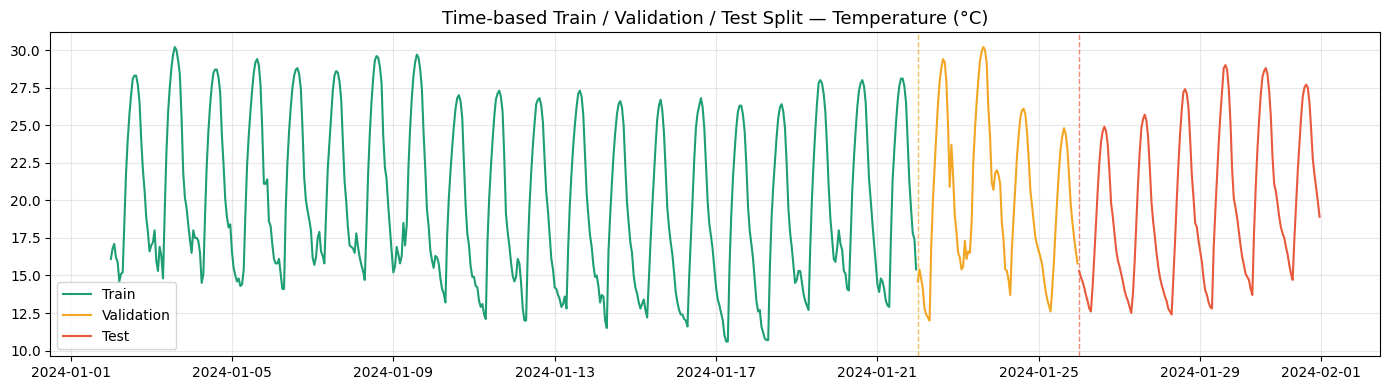

In [73]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(df_train.index, df_train["temperature_2m"], color="#1D9E75", label="Train", linewidth=1.5)
ax.plot(df_val.index,   df_val["temperature_2m"],   color="#F2A623", label="Validation", linewidth=1.5)
ax.plot(df_test.index,  df_test["temperature_2m"],  color="#E8593C", label="Test", linewidth=1.5)


ax.axvline(x=df_val.index.min(),  color="#F2A623", linestyle="--", alpha=0.7, linewidth=1)
ax.axvline(x=df_test.index.min(), color="#E8593C", linestyle="--", alpha=0.7, linewidth=1)

ax.set_title("Time-based Train / Validation / Test Split — Temperature (°C)", fontsize=13)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [75]:
scaler = StandardScaler()
scaler.fit(df_train[cols_to_scale])

df_train_scaled = df_train.copy()
df_val_scaled = df_val.copy()
df_test_scaled = df_test.copy()

df_train_scaled[cols_to_scale] = scaler.transform(df_train[cols_to_scale])
df_val_scaled[cols_to_scale] = scaler.transform(df_val[cols_to_scale])
df_test_scaled[cols_to_scale] = scaler.transform(df_test[cols_to_scale])

print(f"Train: {len(df_train_scaled)} rows")
print(f"val: {len(df_val_scaled)} rows")
print(f"Test:  {len(df_test_scaled)} rows")
print(f"\nTrain mean after scaling (should be ~0):\n{df_train_scaled[cols_to_scale[:3]].mean().round(4)}")
print(df_val_scaled[cols_to_scale[:3]].mean().round(4))

Train: 480 rows
val: 96 rows
Test:  144 rows

Train mean after scaling (should be ~0):
temperature_2m        -0.0
shortwave_radiation   -0.0
windspeed_10m          0.0
dtype: float64
temperature_2m         0.0558
shortwave_radiation    0.0125
windspeed_10m          0.2264
dtype: float64


In [134]:
TARGET = "shortwave_radiation"

target_derivatives = [c for c in df_train_scaled.columns if c.startswith(TARGET)]


exclude = ["station_id", "id"] + target_derivatives

FEATURES = [c for c in df_train_scaled.columns if c not in exclude]

print(f"\nFinal feature count: {len(FEATURES)}")
print("\nFeature list:")
for f in FEATURES:
    print(f"  {f}")


Final feature count: 38

Feature list:
  temperature_2m
  windspeed_10m
  wind_direction_10m
  wind_gusts_10m
  relative_humidity_2m
  rain
  cloud_cover
  soil_temperature_7_to_28cm
  soil_moisture_7_to_28cm
  hour
  day_of_week
  month
  is_weekend
  hour_sin
  hour_cos
  day_of_week_sin
  day_of_weel_cos
  temperature_2m_lag1
  temperature_2m_lag2
  temperature_2m_lag3
  temperature_2m_lag24
  windspeed_10m_lag1
  windspeed_10m_lag2
  windspeed_10m_lag3
  windspeed_10m_lag24
  relative_humidity_2m_lag1
  relative_humidity_2m_lag2
  relative_humidity_2m_lag3
  relative_humidity_2m_lag24
  temperature_2m_rolling3h
  temperature_2m_rolling6h
  temperature_2m_rolling24h
  windspeed_10m_rolling3h
  windspeed_10m_rolling6h
  windspeed_10m_rolling24h
  relative_humidity_2m_rolling3h
  relative_humidity_2m_rolling6h
  relative_humidity_2m_rolling24h


In [136]:
X_train = df_train_scaled[FEATURES]
y_train = df_train_scaled[TARGET]

X_val = df_val_scaled[FEATURES]
y_val = df_val_scaled[TARGET]

X_test = df_test_scaled[FEATURES]
y_test = df_test_scaled[TARGET]

In [137]:
print(f"X_train:{X_train.shape} | y_train: {y_train.shape}")
print(f"X_val:{X_val.shape} | y_val: {y_val.shape}")
print(f"X_test:{X_test.shape} | y_test: {y_test.shape}")


X_train:(480, 38) | y_train: (480,)
X_val:(96, 38) | y_val: (96,)
X_test:(144, 38) | y_test: (144,)


In [138]:
# saving the scaler and splits

os.makedirs("../models", exist_ok=True)
os.makedirs("../data/splits", exist_ok=True)

joblib.dump(scaler, "../models/scaler.joblib")

df_train_scaled.to_parquet("../data/splits/train.parquet")
df_val_scaled.to_parquet("../data/splits/val.parquet")
df_test_scaled.to_parquet("../data/splits/test.parquet")

In [139]:
import json

with open("../models/featuere_config.json", "w") as f:
    json.dump({"features": FEATURES, "target":TARGET}, f, indent=2)

## Day 8 — Baseline: Linear Regression

In [87]:
# # load the splits if  using in diff notebook

# df_train = pd.read_parquet("../data/splits/train.parquet")
# df_val = pd.read_parquet("../data/splits/val.parquet")
# df_test = pd.read_parquet("../data/splits/test.parquet")

# with open("../models/feature_config.json") as f:
#     config = json.load(f)
#     ....

In [104]:
# X_train = df_train[FEATURES]
# y_train = df_train[TARGET]

# X_val = df_val[FEATURES]
# y_val = df_val[TARGET]

# X_test = df_test[FEATURES]
# y_test = df_test[TARGET]

# print(f"X_train:{X_train.shape}")
# print(f"X_val:{X_val.shape}")
# print(f"X_test:{X_test.shape}")

In [274]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


model = LinearRegression()
model.fit(X_train,y_train)

print("Linear Regression details.")
print(f"Intercept : {model.intercept_:.4f}")
print(f"coefficients: {len(model.coef_)}")

Linear Regression details.
Intercept : -0.2113
coefficients: 38


In [208]:
def evaluate(y_true, y_pred, split_name=""):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    # avoiding division error!
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

    print(f"{split_name}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  MAE  : {mae:.4f}")
    print(f"    R2 : {r2:.4f}")
    print(f"  MAPE : {mape:.2f}%")
    return {"rmse": rmse, "mae": mae, "mape": mape, "r2": r2}

val_preds = model.predict(X_val)
train_preds = model.predict(X_train)

train_metrics = evaluate(y_train, train_preds, "Train")
print()
val_metrics = evaluate(y_val, val_preds, "validation")

Train
  RMSE : 0.1677
  MAE  : 0.1326
    R2 : 0.9719
  MAPE : 21.97%

validation
  RMSE : 0.3187
  MAE  : 0.2626
    R2 : 0.9013
  MAPE : 39.58%


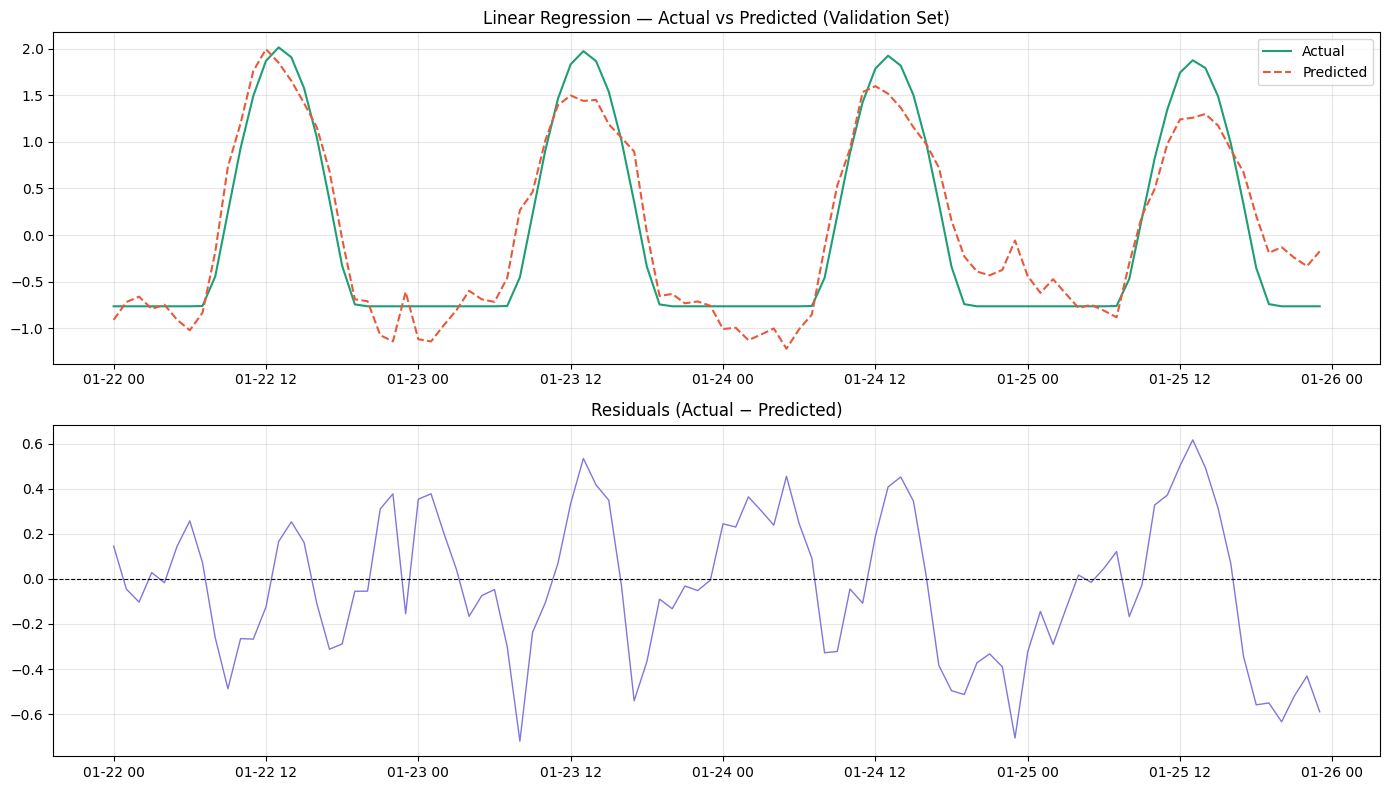

In [142]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(df_val.index, y_val.values,  label="Actual",    color="#1D9E75", linewidth=1.5)
axes[0].plot(df_val.index, val_preds,     label="Predicted", color="#E8593C", linewidth=1.5, linestyle="--")
axes[0].set_title("Linear Regression — Actual vs Predicted (Validation Set)")
axes[0].legend()
axes[0].grid(alpha=0.3)


residuals = y_val.values - val_preds
axes[1].plot(df_val.index, residuals, color="#7F77DD", linewidth=1)
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_title("Residuals (Actual − Predicted)")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

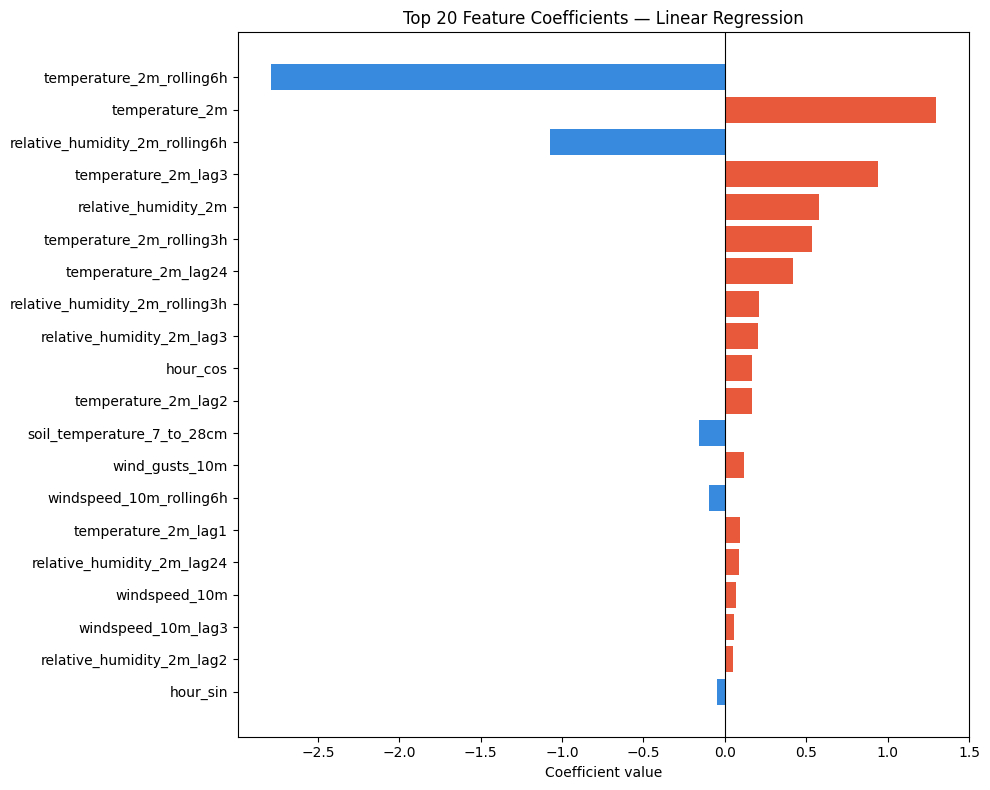


Top 5 most influential features:
                           feature  coefficient
30        temperature_2m_rolling6h    -2.787512
0                   temperature_2m     1.298328
36  relative_humidity_2m_rolling6h    -1.072388
19             temperature_2m_lag3     0.943077
4             relative_humidity_2m     0.579496


In [143]:
coef_df = pd.DataFrame({
    "feature":     FEATURES,
    "coefficient": model.coef_
}).sort_values("coefficient", key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
top20 = coef_df.head(20)
colors = ["#E8593C" if c > 0 else "#378ADD" for c in top20["coefficient"]]

ax.barh(top20["feature"], top20["coefficient"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Top 20 Feature Coefficients — Linear Regression")
ax.set_xlabel("Coefficient value")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 5 most influential features:")
print(coef_df.head())

In [144]:
y_train

timestamp
2024-01-02 00:00:00   -0.764322
2024-01-02 01:00:00   -0.764322
2024-01-02 02:00:00   -0.764322
2024-01-02 03:00:00   -0.764322
2024-01-02 04:00:00   -0.764322
                         ...   
2024-01-21 19:00:00   -0.744183
2024-01-21 20:00:00   -0.764322
2024-01-21 21:00:00   -0.764322
2024-01-21 22:00:00   -0.764322
2024-01-21 23:00:00   -0.764322
Name: shortwave_radiation, Length: 480, dtype: float64

In [275]:
test_preds   = model.predict(X_test)
test_metrics = evaluate(y_test, test_preds, "Test")

print()
print("Baseline Summary")
print(f"  Train RMSE : {train_metrics['rmse']:.4f}")
print(f"  Val RMSE   : {val_metrics['rmse']:.4f}")
print(f"  Test RMSE  : {test_metrics['rmse']:.4f}")
print()

Test
  RMSE : 0.2335
  MAE  : 0.1927
    R2 : 0.9449
  MAPE : 28.27%

Baseline Summary
  Train RMSE : 0.1677
  Val RMSE   : 0.3187
  Test RMSE  : 0.2335



In [276]:
regression_accuracy = 100 - 28.27
print(f"regression_accuracy:{regression_accuracy}%")

regression_accuracy:71.73%


In [277]:
results = {
    "linear_regression": {
        # "train": train_metrics,
        "val": val_metrics,
        "test": test_metrics
    }
}

with open("../models/baseline_linear_regression.json", "w") as f:
    json.dump(results, f, indent=2)

print("models/baseline_linear_regression")



models/baseline_linear_regression


## Day 09 - XGBoost &  RandomForest

In [209]:
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor


rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_val = rf_model.predict(X_val)
rf_test = rf_model.predict(X_test)

rf_val_metrics = evaluate(y_val, rf_val, "RandomForest Val")
print()
rf_test_metrics = evaluate(y_test, rf_test, "RandomForest Test")


RandomForest Val
  RMSE : 0.1057
  MAE  : 0.0610
    R2 : 0.9891
  MAPE : 10.84%

RandomForest Test
  RMSE : 0.1137
  MAE  : 0.0551
    R2 : 0.9869
  MAPE : 11.28%


In [210]:
xgb_model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    early_stopping_rounds=50,
    eval_metric="rmse",
    verbosity=0
)

xgb_model.fit(X_train, y_train,
             eval_set=[(X_val, y_val)],
             verbose=False
             )

xgb_val = xgb_model.predict(X_val)
xgb_test = xgb_model.predict(X_test)

xgb_val_metrics = evaluate(y_val, xgb_val)
print()
xgb_test_metrics = evaluate(y_test, xgb_test)


  RMSE : 0.1494
  MAE  : 0.1038
    R2 : 0.9783
  MAPE : 15.76%


  RMSE : 0.1315
  MAE  : 0.0834
    R2 : 0.9825
  MAPE : 14.01%


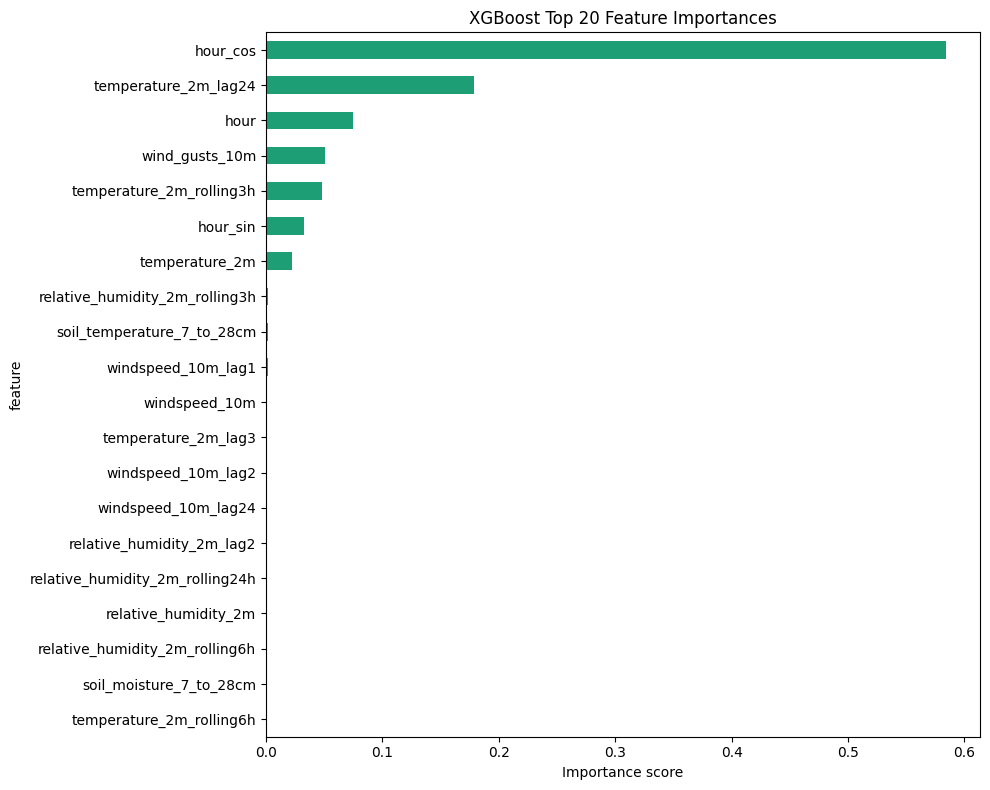

                     feature  importance
14                  hour_cos    0.584124
20      temperature_2m_lag24    0.178641
9                       hour    0.074519
3             wind_gusts_10m    0.050627
29  temperature_2m_rolling3h    0.047974


In [172]:
importance_df = pd.DataFrame({
    "feature" : FEATURES,
    "importance": xgb_model.feature_importances_
}).sort_values("importance", ascending=False)

fig, ax = plt.subplots(figsize=(10,8))
importance_df.head(20).plot(
    kind="barh", x="feature", y="importance",
    ax=ax, color="#1D9E75", legend=False
)

ax.set_title("XGBoost Top 20 Feature Importances")
ax.set_xlabel("Importance score")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(importance_df.head())

In [219]:
with open("../models/results.json", "r") as f:
    results = json.load(f)

results["random_forest"] = {
    "val":  rf_val_metrics,
    "test": rf_test_metrics
}
results["xgboost_default"] = {
    "val":  xgb_val_metrics,
    "test": xgb_test_metrics
}


print(f"{'Model':<28} {'Val RMSE':>10} {'Test RMSE':>10} {'R²':>6}")

for model_name, metrics in results.items():
    val_rmse  = metrics.get("val", {}).get("rmse", 0.0)
    test_rmse = metrics.get("test", {}).get("rmse", 0.0)
    r2        = metrics.get("test", {}).get("r2", 0.0)
    print(f"{model_name:<28} {val_rmse:>10.4f} {test_rmse:>10.4f} {r2:>6.4f}")

Model                          Val RMSE  Test RMSE     R²
linear_regression                0.3187     0.2335 0.9449
random_forest                    0.1057     0.1137 0.9869
xgboost_default                  0.1494     0.1315 0.9825


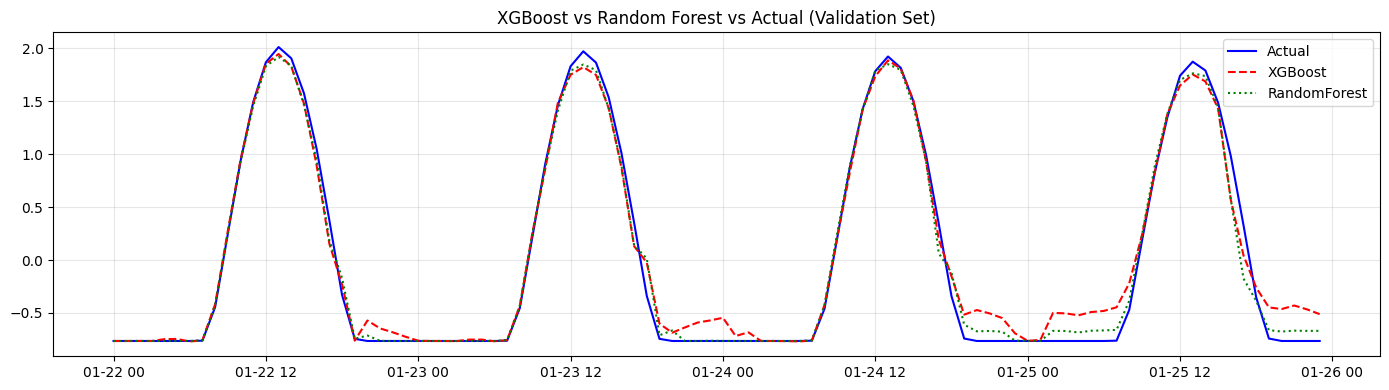

In [221]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(df_val.index, y_val.values, label="Actual", color="Blue", linewidth=1.5)
ax.plot(df_val.index, xgb_val, label="XGBoost", color="REd", linewidth=1.5, linestyle="--")
ax.plot(df_val.index, rf_val, label="RandomForest", color="Green", linewidth=1.5, linestyle=":")

ax.set_title("XGBoost vs Random Forest vs Actual (Validation Set)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Day 10- Hyperparameter Tuning with Optuna

In [228]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        "n_estimators":  trial.suggest_int("n_estimators", 200, 1000),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "reg_alpha":  trial.suggest_float("reg_alpha", 1e-8, 1.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 1.0, log=True),
        "random_state": 42,
        "verbosity": 0,
        "eval_metric": "rmse",
        "early_stopping_rounds": 50,
    }

    model = xgb.XGBRegressor(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    preds = model.predict(X_val)
    return np.sqrt(mean_squared_error(y_val, preds))


study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\nBest Val RMSE : {study.best_value:.4f}")
print(f"Best params   :")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

  0%|          | 0/50 [00:00<?, ?it/s]


Best Val RMSE : 0.0799
Best params   :
  n_estimators: 716
  max_depth: 6
  learning_rate: 0.28042739745174006
  subsample: 0.7485719040813565
  colsample_bytree: 0.9989561876178842
  min_child_weight: 4
  reg_alpha: 6.312874488308385e-07
  reg_lambda: 0.0009575656377262497


In [231]:
best_params = study.best_params
best_params.update({
    "random_state": 42,
    "verbosity": 0,
    "eval_metric": "rmse",
    "early_stopping_rounds": 50
})

xgb_tuned = xgb.XGBRegressor(**best_params)
xgb_tuned.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

print(f"Tuned model best iteration: {xgb_tuned.best_iteration}")

tuned_val_preds = xgb_tuned.predict(X_val)
tuned_test_preds = xgb_tuned.predict(X_test)

tuned_val_metrics = evaluate(y_val, tuned_val_preds, "Tuned XGBoost - Val")
print()
tuned_test_metrics = evaluate(y_test, tuned_test_preds, "Tuned XGBoost - Test")

Tuned model best iteration: 25
Tuned XGBoost - Val
  RMSE : 0.0799
  MAE  : 0.0495
    R2 : 0.9938
  MAPE : 8.86%

Tuned XGBoost - Test
  RMSE : 0.1292
  MAE  : 0.0544
    R2 : 0.9831
  MAPE : 10.17%


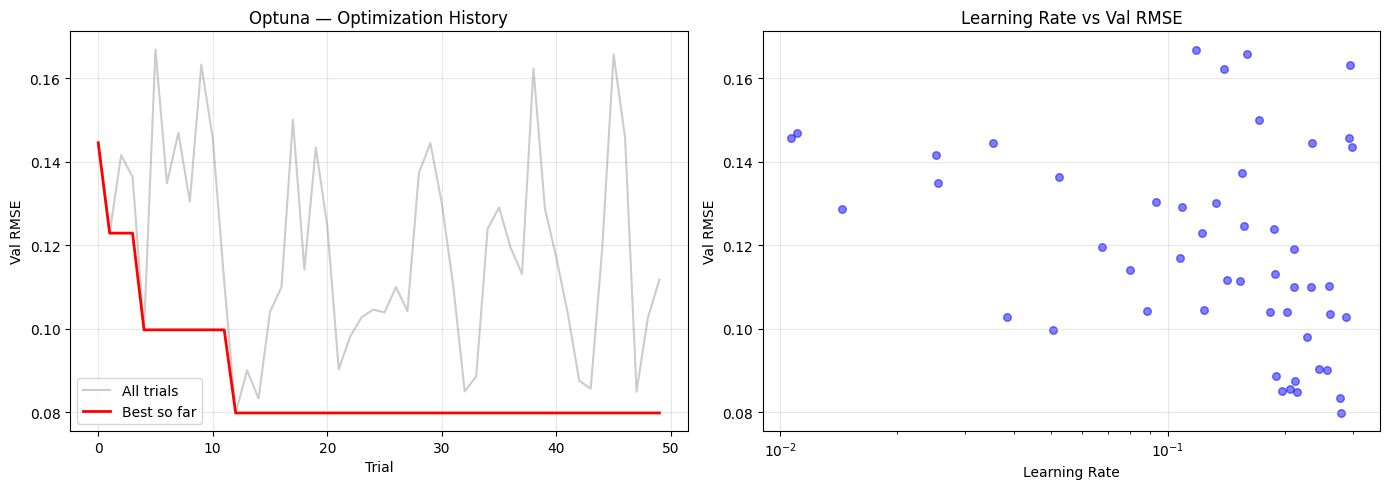

In [235]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

trials_df = study.trials_dataframe()
axes[0].plot(trials_df["value"], alpha=0.4, color="grey", label="All trials")
axes[0].plot(
    trials_df["value"].cummin(),
    color="red", linewidth=2, label="Best so far"
)
axes[0].set_title("Optuna — Optimization History")
axes[0].set_xlabel("Trial")
axes[0].set_ylabel("Val RMSE")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].scatter(
    trials_df["params_learning_rate"],
    trials_df["value"],
    alpha=0.5, color="blue", s=30
)
axes[1].set_title("Learning Rate vs Val RMSE")
axes[1].set_xlabel("Learning Rate")
axes[1].set_ylabel("Val RMSE")
axes[1].set_xscale("log")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [236]:
results["xgboost_tuned"] = {
    "val": tuned_val_metrics,
    "test": tuned_test_metrics,
    "best_params": study.best_params
}

with open("../models/results.json", "w") as f:
    json.dump(results, f, indent=2)

joblib.dump(xgb_tuned, "../models/xgboost_tuned.joblib")

['../models/xgboost_tuned.joblib']

In [238]:
print(f"{'Model':<28} {'Val RMSE':>10} {'Test RMSE':>10} {'R²':>6}")
for model_name, metrics in results.items():
    val_rmse  = metrics.get("val", {}).get("rmse", "-")
    test_rmse = metrics.get("test", {}).get("rmse", "-")
    r2        = metrics.get("test", {}).get("r2", "-")
    if isinstance(val_rmse, float):
        print(f"{model_name:<28} {val_rmse:>10.4f} {test_rmse:>10.4f} {r2:>6.4f}")
print()
print(f"Target for Day 14 LSTM: beat Val RMSE {tuned_val_metrics['rmse']:.4f}")

Model                          Val RMSE  Test RMSE     R²
linear_regression                0.3187     0.2335 0.9449
random_forest                    0.1057     0.1137 0.9869
xgboost_default                  0.1494     0.1315 0.9825
xgboost_tuned                    0.0799     0.1292 0.9831

Target for Day 14 LSTM: beat Val RMSE 0.0799


In [244]:
#randon forest because it has small differnce between the val RMSE and the Test RMSE
# and indication of more generalising

joblib.dump(rf_model, "../models/production_model.joblib")
print("Production model saved -> models/production_model.joblib")

Production model saved -> models/production_model.joblib


In [261]:
df_train = pd.read_parquet("../data/splits/train.parquet")
df_val = pd.read_parquet("../data/splits/val.parquet")
df_test = pd.read_parquet("../data/splits/test.parquet")


X_train, y_train = df_train[FEATURES], df_train[TARGET]
X_val,   y_val   = df_val[FEATURES],   df_val[TARGET]
X_test,  y_test  = df_test[FEATURES],  df_test[TARGET]

In [262]:
print(f"y_train mean: {y_train.mean():.4f}  (should be close to 0 if scaled)")
print(f"y_train std : {y_train.std():.4f}   (should be close to 1 if scaled)")
print()
print(f"y_test mean : {y_test.mean():.4f}")
print(f"y_test std  : {y_test.std():.4f}")

y_train mean: -0.0000  (should be close to 0 if scaled)
y_train std : 1.0010   (should be close to 1 if scaled)

y_test mean : -0.0029
y_test std  : 0.9979


In [264]:
def full_evaluate(y_true, y_pred, model_name="", split_name=""):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)

    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

    max_err = np.max(np.abs(y_true - y_pred))

    mbe = np.mean(y_pred - y_true)

    print(f"  {model_name} — {split_name}")
    print(f"  RMSE     : {rmse:.4f}   (lower is better)")
    print(f"  MAE      : {mae:.4f}   (lower is better)")
    print(f"  MAPE     : {mape:.2f}%  (daytime hours only)")
    print(f"  R²       : {r2:.4f}   (higher is better)")
    print(f"  Max Error: {max_err:.4f}  (worst prediction)")
    print(f"  Bias     : {mbe:.4f}   (+ over, - under predicts)")
    print()

    return {
        "rmse": rmse, "mae": mae, "mape": mape,
        "r2": r2, "max_error": max_err, "bias": mbe
    }

In [265]:
rf_preds = {
    "train": rf_model.predict(X_train),
    "val": rf_model.predict(X_val),
    "test": rf_model.predict(X_test)
}

xgb_preds = {
    "train": xgb_tuned.predict(X_train),
    "val": xgb_tuned.predict(X_val),
    "test": xgb_tuned.predict(X_test)
}

print("Random Forest")
rf_metrics = {}

for split, y_true in [("train", y_train), ("val", y_val), ("test", y_test)]:
    rf_metrics[split] = full_evaluate(y_true, rf_preds[split], "Random Forest", split)

print("XGB Tuned")
xgb_metrics = {}
for split, y_true in [("train", y_train), ("val", y_val), ("test", y_test)]:
    xgb_metrics[split] = full_evaluate(y_true, xgb_preds[split], "XGBoost Tuned", split)

Random Forest
  Random Forest — train
  RMSE     : 0.0349   (lower is better)
  MAE      : 0.0140   (lower is better)
  MAPE     : 2.52%  (daytime hours only)
  R²       : 0.9988   (higher is better)
  Max Error: 0.3032  (worst prediction)
  Bias     : -0.0004   (+ over, - under predicts)

  Random Forest — val
  RMSE     : 0.1057   (lower is better)
  MAE      : 0.0610   (lower is better)
  MAPE     : 10.84%  (daytime hours only)
  R²       : 0.9891   (higher is better)
  Max Error: 0.5040  (worst prediction)
  Bias     : -0.0030   (+ over, - under predicts)

  Random Forest — test
  RMSE     : 0.1137   (lower is better)
  MAE      : 0.0551   (lower is better)
  MAPE     : 11.28%  (daytime hours only)
  R²       : 0.9869   (higher is better)
  Max Error: 0.6670  (worst prediction)
  Bias     : -0.0052   (+ over, - under predicts)

XGB Tuned
  XGBoost Tuned — train
  RMSE     : 0.0041   (lower is better)
  MAE      : 0.0025   (lower is better)
  MAPE     : 0.40%  (daytime hours only)
 

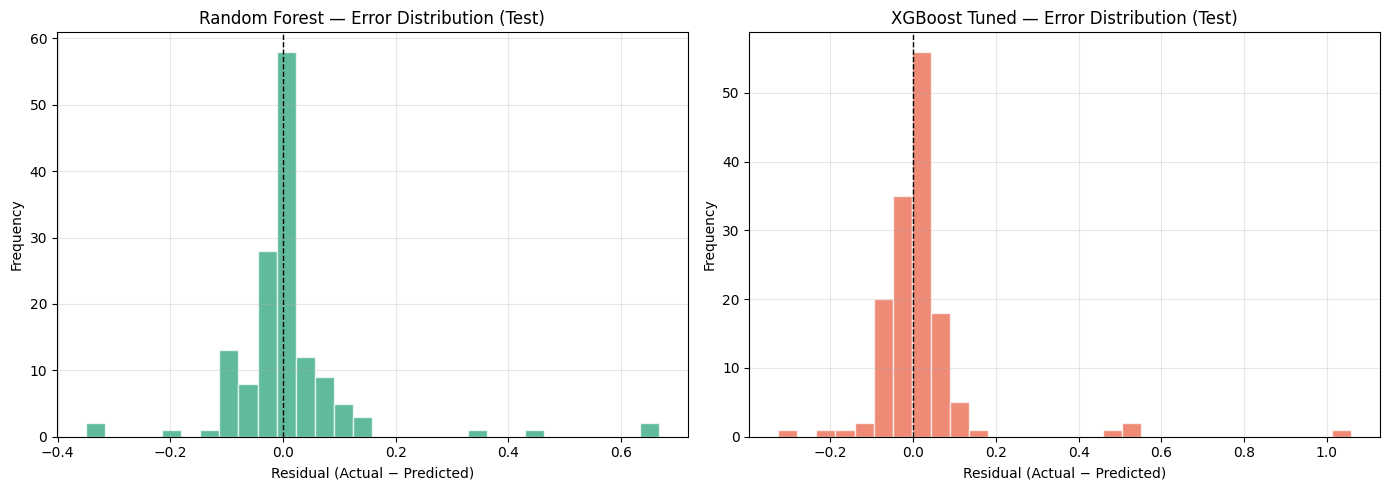

A good model has errors centred at 0 with a bell shape.
Skew to one side means the model consistently over or under predicts.


In [266]:
rf_test_errors  = y_test.values - rf_preds["test"]
xgb_test_errors = y_test.values - xgb_preds["test"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(rf_test_errors,  bins=30, color="#1D9E75", alpha=0.7, edgecolor="white")
axes[0].axvline(0, color="black", linewidth=1, linestyle="--")
axes[0].set_title("Random Forest — Error Distribution (Test)")
axes[0].set_xlabel("Residual (Actual − Predicted)")
axes[0].set_ylabel("Frequency")
axes[0].grid(alpha=0.3)

axes[1].hist(xgb_test_errors, bins=30, color="#E8593C", alpha=0.7, edgecolor="white")
axes[1].axvline(0, color="black", linewidth=1, linestyle="--")
axes[1].set_title("XGBoost Tuned — Error Distribution (Test)")
axes[1].set_xlabel("Residual (Actual − Predicted)")
axes[1].set_ylabel("Frequency")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("A good model has errors centred at 0 with a bell shape.")
print("Skew to one side means the model consistently over or under predicts.")

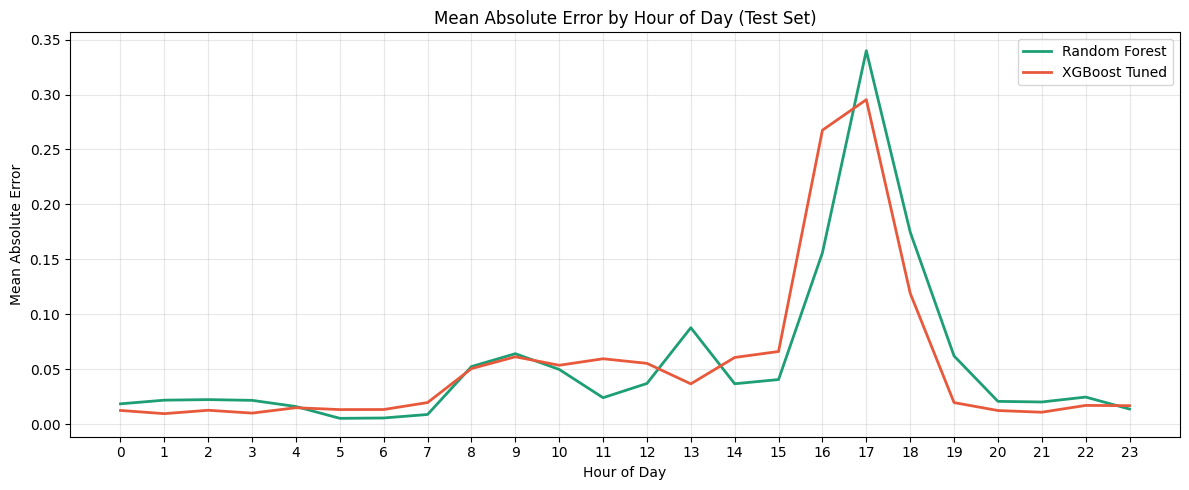

Peak error hours reveal where the model struggles most.
For solar radiation expect highest errors around sunrise/sunset transitions.


In [267]:
# this reveals the times when the model struggles most during the day
test_analysis = df_test.copy()
test_analysis["rf_error"]  = np.abs(rf_test_errors)
test_analysis["xgb_error"] = np.abs(xgb_test_errors)
test_analysis["hour"]      = test_analysis.index.hour

hourly_errors = test_analysis.groupby("hour")[["rf_error", "xgb_error"]].mean()

fig, ax = plt.subplots(figsize=(12, 5))
hourly_errors["rf_error"].plot(ax=ax,  label="Random Forest", color="#1D9E75", linewidth=2)
hourly_errors["xgb_error"].plot(ax=ax, label="XGBoost Tuned", color="#E8593C", linewidth=2)

ax.set_title("Mean Absolute Error by Hour of Day (Test Set)")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Mean Absolute Error")
ax.set_xticks(range(0, 24))
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Peak error hours reveal where the model struggles most.")
print("For solar radiation expect highest errors around sunrise/sunset transitions.")

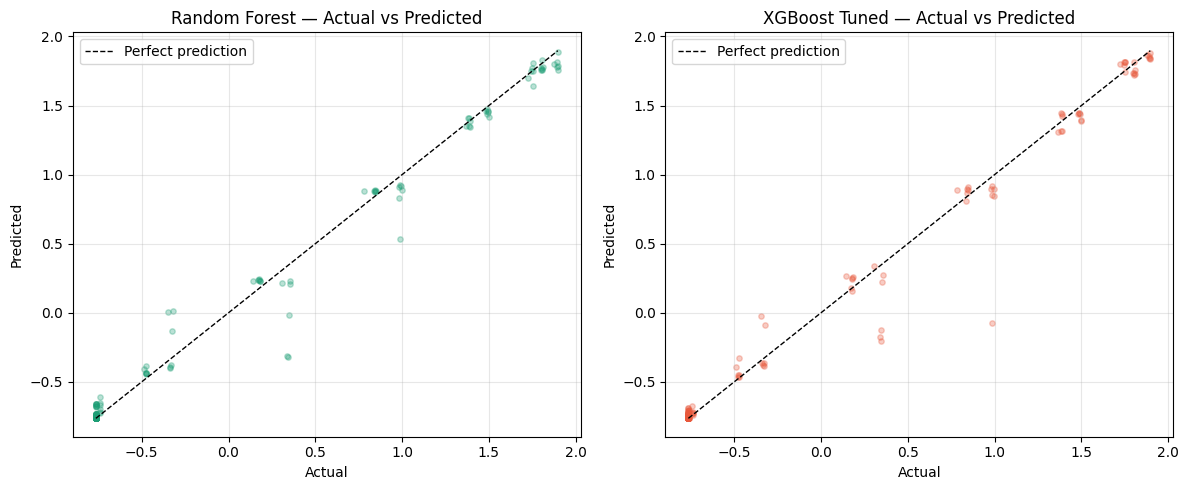

Dots close to the diagonal line = accurate predictions.
Dots far from the line = large errors.
A fan shape means error grows with the value — common in solar radiation.


In [270]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, preds, name, color in [
    (axes[0], rf_preds["test"],  "Random Forest", "#1D9E75"),
    (axes[1], xgb_preds["test"], "XGBoost Tuned", "#E8593C")
]:
    ax.scatter(y_test, preds, alpha=0.3, color=color, s=15)
    
    # perfect prediction line
    min_val = min(y_test.min(), preds.min())
    max_val = max(y_test.max(), preds.max())
    ax.plot([min_val, max_val], [min_val, max_val], 
            color="black", linewidth=1, linestyle="--", label="Perfect prediction")
    
    ax.set_title(f"{name} — Actual vs Predicted")
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Dots close to the diagonal line = accurate predictions.")
print("Dots far from the line = large errors.")
print("A fan shape means error grows with the value — common in solar radiation.")

## Day -12

In [271]:
with open("../models/results.json") as f:
    all_results = json.load(f)


rows = []
for model_name, metrics in all_results.items():
    row = {
        "model":      model_name,
        "val_rmse":   metrics.get("val",  {}).get("rmse",  None),
        "test_rmse":  metrics.get("test", {}).get("rmse",  None),
        "test_r2":    metrics.get("test", {}).get("r2",    None),
        "test_mae":   metrics.get("test", {}).get("mae",   None),
    }
    rows.append(row)

summary_df = pd.DataFrame(rows).set_index("model")
summary_df = summary_df.sort_values("test_rmse")

print("=" * 65)
print(f"{'Model':<28} {'Val RMSE':>10} {'Test RMSE':>10} {'R²':>8} {'MAE':>8}")
print("=" * 65)
for model, row in summary_df.iterrows():
    print(f"{model:<28} {row['val_rmse']:>10.4f} {row['test_rmse']:>10.4f} "
          f"{row['test_r2']:>8.4f} {row['test_mae']:>8.4f}")
print("=" * 65)

Model                          Val RMSE  Test RMSE       R²      MAE
random_forest                    0.1057     0.1137   0.9869   0.0551
xgboost_tuned                    0.0799     0.1292   0.9831   0.0544
xgboost_default                  0.1494     0.1315   0.9825   0.0834
linear_regression                0.3187     0.2335   0.9449   0.1927


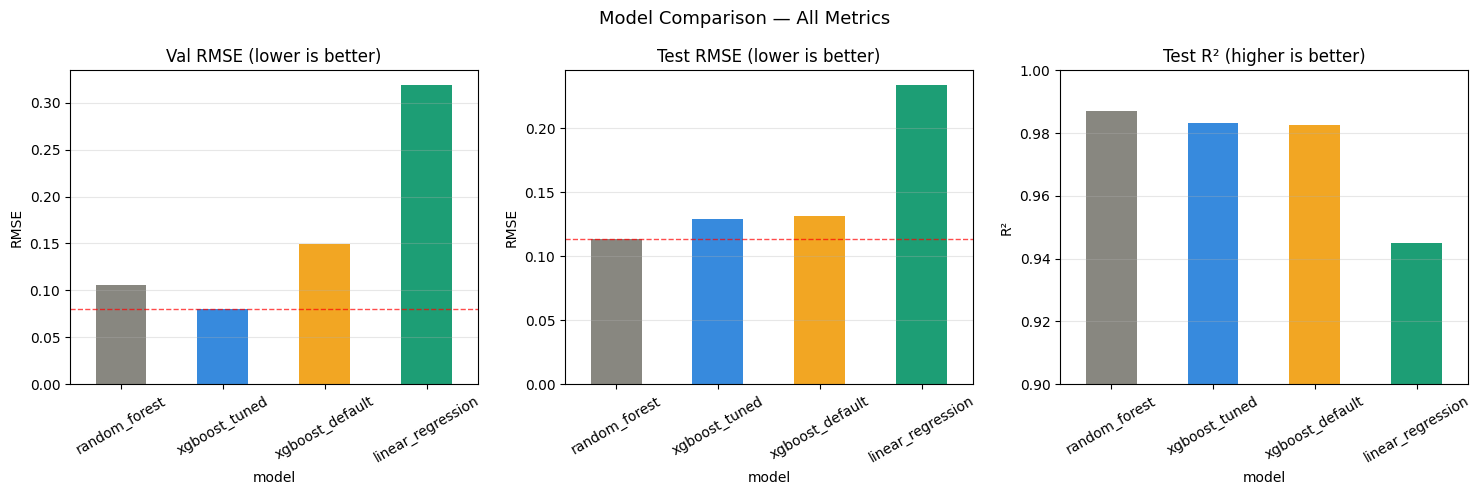

In [272]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Model Comparison — All Metrics", fontsize=13)

colors = ["#888780", "#378ADD", "#F2A623", "#1D9E75"]

# Val RMSE
summary_df["val_rmse"].plot(kind="bar", ax=axes[0], color=colors, rot=30)
axes[0].set_title("Val RMSE (lower is better)")
axes[0].set_ylabel("RMSE")
axes[0].grid(alpha=0.3, axis="y")
axes[0].axhline(summary_df["val_rmse"].min(), color="red", 
                linestyle="--", linewidth=1, alpha=0.7)

# Test RMSE
summary_df["test_rmse"].plot(kind="bar", ax=axes[1], color=colors, rot=30)
axes[1].set_title("Test RMSE (lower is better)")
axes[1].set_ylabel("RMSE")
axes[1].grid(alpha=0.3, axis="y")
axes[1].axhline(summary_df["test_rmse"].min(), color="red",
                linestyle="--", linewidth=1, alpha=0.7)

# R²
summary_df["test_r2"].plot(kind="bar", ax=axes[2], color=colors, rot=30)
axes[2].set_title("Test R² (higher is better)")
axes[2].set_ylabel("R²")
axes[2].grid(alpha=0.3, axis="y")
axes[2].set_ylim(0.9, 1.0)

plt.tight_layout()
plt.show()

In [282]:
best_model_name = summary_df["test_rmse"].idxmin()
best_row        = summary_df.loc[best_model_name]

print("=" * 50)
print("         MODEL CARD")
print("=" * 50)
print(f"  Target variable : {TARGET}")
print(f"  Best model      : {best_model_name}")
print(f"  Training period : Jan 1 → Jan 21 2024")
print(f"  Val period      : Jan 22 → Jan 25 2024")
print(f"  Test period     : Jan 26 → Jan 31 2024")
print(f"  Features used   : {len(FEATURES)}")
print()
print(f"  Test RMSE  : {best_row['test_rmse']:.4f}")
print(f"  Test MAE   : {best_row['test_mae']:.4f}")
print(f"  Test R²    : {best_row['test_r2']:.4f}")
print()
print(f"  Production model : models/production_model.joblib")
print(f"  Scaler           : models/scaler.joblib")
print(f"  Feature config   : models/feature_config.json")
print()
print("  Known limitations:")
print("  - Trained on 1 month of data only")
print("  - MAPE unreliable due to zero radiation at night")
print("  - Will need retraining as more station data arrives")
print("=" * 50)

         MODEL CARD
  Target variable : shortwave_radiation
  Best model      : random_forest
  Training period : Jan 1 → Jan 21 2024
  Val period      : Jan 22 → Jan 25 2024
  Test period     : Jan 26 → Jan 31 2024
  Features used   : 38

  Test RMSE  : 0.1137
  Test MAE   : 0.0551
  Test R²    : 0.9869

  Production model : models/production_model.joblib
  Scaler           : models/scaler.joblib
  Feature config   : models/feature_config.json

  Known limitations:
  - Trained on 1 month of data only
  - MAPE unreliable due to zero radiation at night
  - Will need retraining as more station data arrives


## Day 13 — Model Persistence

In [287]:
from datetime import datetime

In [288]:
#saving production model
joblib.dump(rf_model, "../models/production_model.joblib")

joblib.dump(model, "../models/baseline_linear_regression.joblib")

#full result
with open("../models/results.json", "w") as f:
    json.dump(all_results, f, indent=2)

model_card = {
    "production_model":  "random_forest",
    "target":            TARGET,
    "features":          FEATURES,
    "feature_count":     len(FEATURES),
    "training_period":   "2024-01-01 to 2024-01-21",
    "val_period":        "2024-01-22 to 2024-01-25",
    "test_period":       "2024-01-26 to 2024-01-31",
    "test_rmse":         float(summary_df.loc["random_forest", "test_rmse"]),
    "test_r2":           float(summary_df.loc["random_forest", "test_r2"]),
    "saved_at":          datetime.now().isoformat(),
    "limitations": [
        "Trained on 1 month of data only",
        "MAPE unreliable for solar radiation due to nighttime zeros",
        "Requires retraining as more API data arrives"
    ]
}

with open("../models/model_card.json", "w") as f:
    json.dump(model_card, f, indent=2)


In [291]:
#checking if all is good
loaded_model = joblib.load("../models/production_model.joblib")
loaded_scaler = joblib.load("../models/scaler.joblib")

with open("../models/feature_config.json") as f:
    loaded_config = json.load(f)

with open("../models/model_card.json") as f:
    loaded_card = json.load(f)

sample_input = X_test.iloc[:1]
sample_pred = loaded_model.predict(sample_input)
actual_value = y_test.iloc[0]


print(f"Model type    : {type(loaded_model).__name__}")
print(f"Features      : {len(loaded_config['features'])}")
print(f"Target        : {loaded_config['target']}")
print(f"Test RMSE     : {loaded_card['test_rmse']:.4f}")
print(f"Saved at      : {loaded_card['saved_at']}")
print()
print(f"Sample prediction : {sample_pred[0]:.4f}")
print(f"Actual value      : {actual_value:.4f}")
print(f"Error             : {abs(sample_pred[0] - actual_value):.4f}")

Model type    : RandomForestRegressor
Features      : 38
Target        : shortwave_radiation
Test RMSE     : 0.1137
Saved at      : 2026-07-15T21:01:52.912183

Sample prediction : -0.6635
Actual value      : -0.7643
Error             : 0.1008
